In [3]:
import random
import math
import sympy as sp
from matplotlib import pyplot as plt
import numpy as np
from tabulate import tabulate

Exercice 3 du TD 5

3. Un bureau de poste dispose de 2 employé·e·s. Alice entre dans le bureau de poste
tandis que 2 autres client·e·s, Bob et Claire, sont servi·e·s par les 2 employé·e·s.
Alice est la prochaine en ligne. Supposons que le temps qu’un·e employé·e passe à
servir un client suit une loi Exp(λ).
Quelle est la probabilité qu’Alice soit la dernière des 3 client·e·s à être servie ?

Solution Analytique

Loi exponentielle :

X∼Exp(λ), variable aléatoire X suivant une loi exponentielle

In [11]:
def prob_alice_last(n_simulations=200_000, rate_lambda=1.0):
    X = np.random.exponential(scale=1/rate_lambda, size=n_simulations) # Bob
    Y = np.random.exponential(scale=1/rate_lambda, size=n_simulations) # Claire
    Z = np.random.exponential(scale=1/rate_lambda, size=n_simulations) # Alice

    alice_finish = np.where(X <= Y, X + Z, Y + Z)
    other_finish = np.where(X <= Y, Y, X)

    alice_last = alice_finish > other_finish

    # Probabilité estimée
    return np.mean(alice_last)

In [12]:
prob = prob_alice_last()
print(f"Probabilité qu'Alice soit servie en dernier : {prob:.3f}")

Probabilité qu'Alice soit servie en dernier : 0.500


Solution par simulation


Probabilité qu'Alice soit la dernière par simulation

╒═════════════════════════╤═══════════════════════╕
│   Nombre de simulations │   Probabilité simulée │
╞═════════════════════════╪═══════════════════════╡
│                      10 │               0.4     │
├─────────────────────────┼───────────────────────┤
│                     100 │               0.5     │
├─────────────────────────┼───────────────────────┤
│                    1000 │               0.478   │
├─────────────────────────┼───────────────────────┤
│                   10000 │               0.4942  │
├─────────────────────────┼───────────────────────┤
│                  100000 │               0.50072 │
├─────────────────────────┼───────────────────────┤
│                 1000000 │               0.50036 │
╘═════════════════════════╧═══════════════════════╛


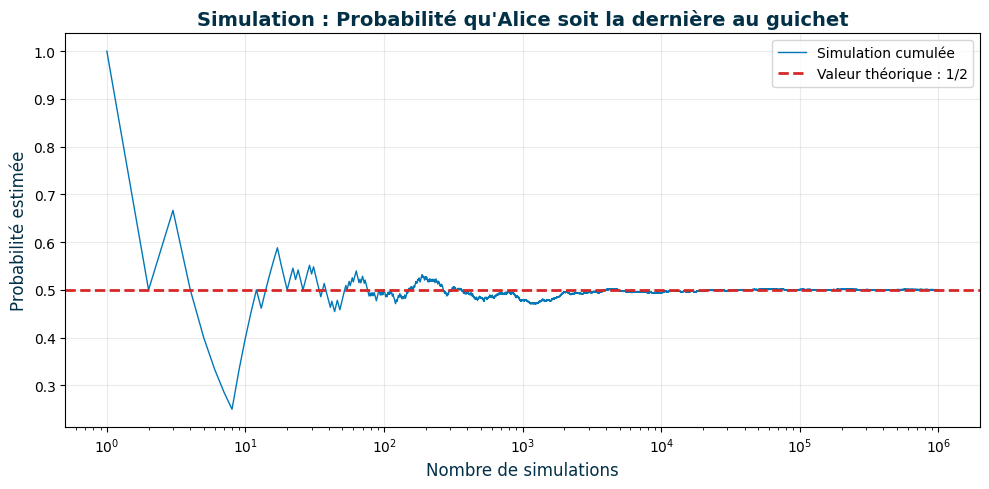

In [5]:
n_sim_total = 1000000
steps = [10, 100, 1000, 10000, 100000, n_sim_total]

alice_last = 0
results = []
cumulative_props = []

for i in range(1, n_sim_total + 1):
    alice_time = np.random.exponential(1)
    remaining_time = np.random.exponential(1)

    if alice_time > remaining_time:
        alice_last += 1

    cumulative_props.append(alice_last / i)

    if i in steps:
        results.append([i, round(alice_last / i, 5)])

print("\nProbabilité qu'Alice soit la dernière par simulation\n")
print(tabulate(results, headers=["Nombre de simulations", "Probabilité simulée"], tablefmt="fancy_grid"))

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_sim_total + 1), cumulative_props, color='#0077b6', linewidth=1, label='Simulation cumulée')
plt.axhline(0.5, color='#d62828', linestyle='--', linewidth=2, label='Valeur théorique : 1/2')

plt.title("Simulation : Probabilité qu'Alice soit la dernière au guichet", fontsize=14, fontweight="bold", color="#023047")
plt.xlabel("Nombre de simulations", fontsize=12, color="#023047")
plt.ylabel("Probabilité estimée", fontsize=12, color="#023047")
plt.xscale('log')  # Améliorer la visualisation
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Simulation afin de trouver la valeur de pi

In [6]:
n_points = 1000  # nombre total de points à projeter


points_in_circle = 0
x_in, y_in = [], []
x_out, y_out = [], []

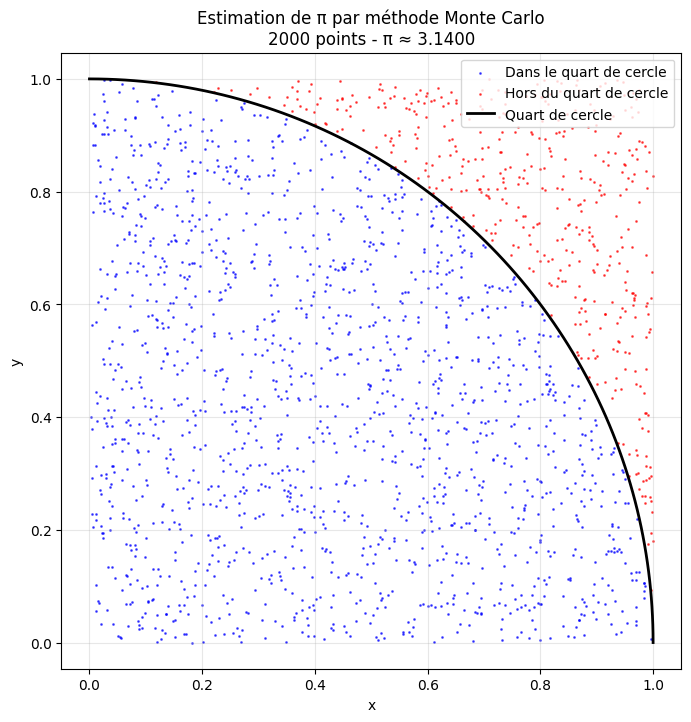

Estimation avec 2000 points: π ≈ 3.140000 (erreur: 0.001593)


In [7]:
np.random.seed(42)  # Pour la reproductibilité


def estimate_pi(n_points):
    """Estime π en utilisant n_points générés aléatoirement"""
    x = np.random.uniform(0, 1, n_points)
    y = np.random.uniform(0, 1, n_points)
    distances = x**2 + y**2
    inside_circle = np.sum(distances <= 1)
    return 4 * inside_circle / n_points

# =============================================================================
# PARTIE 1: VISUALISATION GÉOMÉTRIQUE
# =============================================================================

def plot_monte_carlo(n_points=1000):
    """Visualise les points dans le carré unité"""
    x = np.random.uniform(0, 1, n_points)
    y = np.random.uniform(0, 1, n_points)
    distances = x**2 + y**2
    dans_quartcercle = distances <= 1

    x_in = x[dans_quartcercle]
    y_in = y[dans_quartcercle]
    x_out = x[~dans_quartcercle]
    y_out = y[~dans_quartcercle]

    pi_estimate = 4 * len(x_in) / n_points

    plt.figure(figsize=(8, 8))
    plt.scatter(x_in, y_in, color='blue', s=1, alpha=0.6, label='Dans le quart de cercle')
    plt.scatter(x_out, y_out, color='red', s=1, alpha=0.6, label='Hors du quart de cercle')

    # Tracer le quart de cercle
    theta = np.linspace(0, np.pi/2, 100)
    plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label='Quart de cercle')

    plt.title(f'Estimation de π par méthode Monte Carlo\n{n_points} points - π ≈ {pi_estimate:.4f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return pi_estimate

# Exécuter la visualisation
pi_est = plot_monte_carlo(2000)
print(f"Estimation avec 2000 points: π ≈ {pi_est:.6f} (erreur: {abs(pi_est-np.pi):.6f})")

Loi des Grands Nombres (LLN)

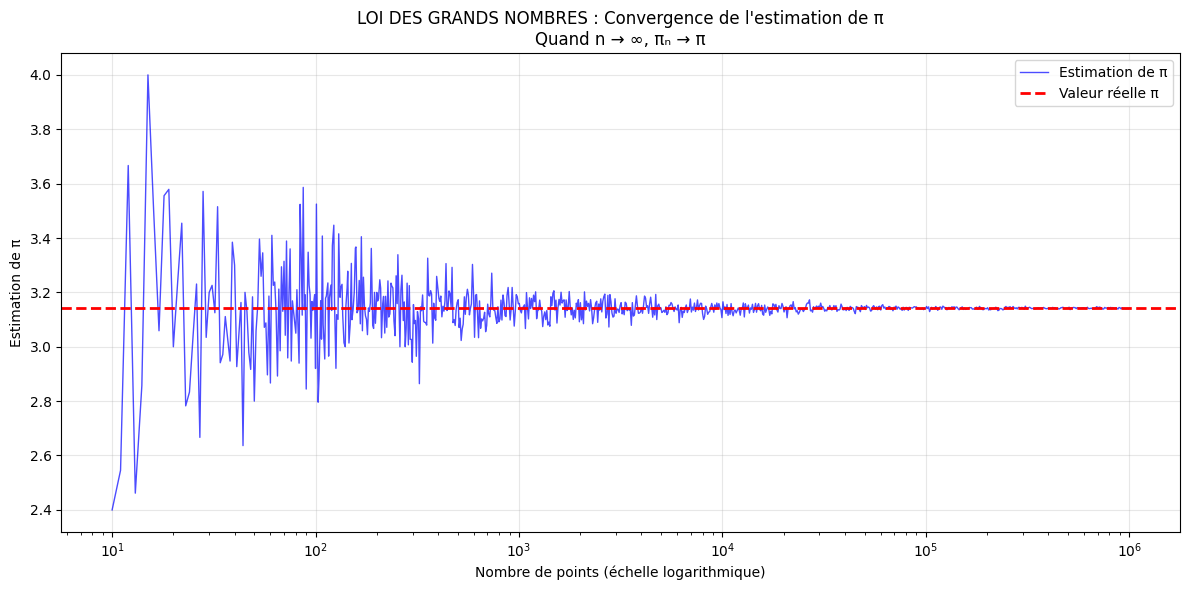

In [9]:
from scipy import stats

étapes = np.logspace(1, 6, 1000, dtype=int)
étapes = np.unique(étapes)

estimations_de_pi = []
for n in étapes:
    estimations_de_pi.append(estimate_pi(n))

plt.figure(figsize=(12, 6))
plt.semilogx(étapes, estimations_de_pi, 'b-', alpha=0.7, linewidth=1, label='Estimation de π')
plt.axhline(y=np.pi, color='r', linestyle='--', linewidth=2, label='Valeur réelle π')

plt.xlabel('Nombre de points (échelle logarithmique)')
plt.ylabel('Estimation de π')
plt.title('LOI DES GRANDS NOMBRES : Convergence de l\'estimation de π\nQuand n → ∞, πₙ → π')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





Théorème centrale limite

THÉORÈME CENTRAL LIMITE : Distribution des estimateurs de π
Calcul des distributions...
✓ 10 points : 1000 simulations terminées
✓ 100 points : 1000 simulations terminées
✓ 1000 points : 1000 simulations terminées
✓ 10000 points : 1000 simulations terminées

HISTOGRAMMES 


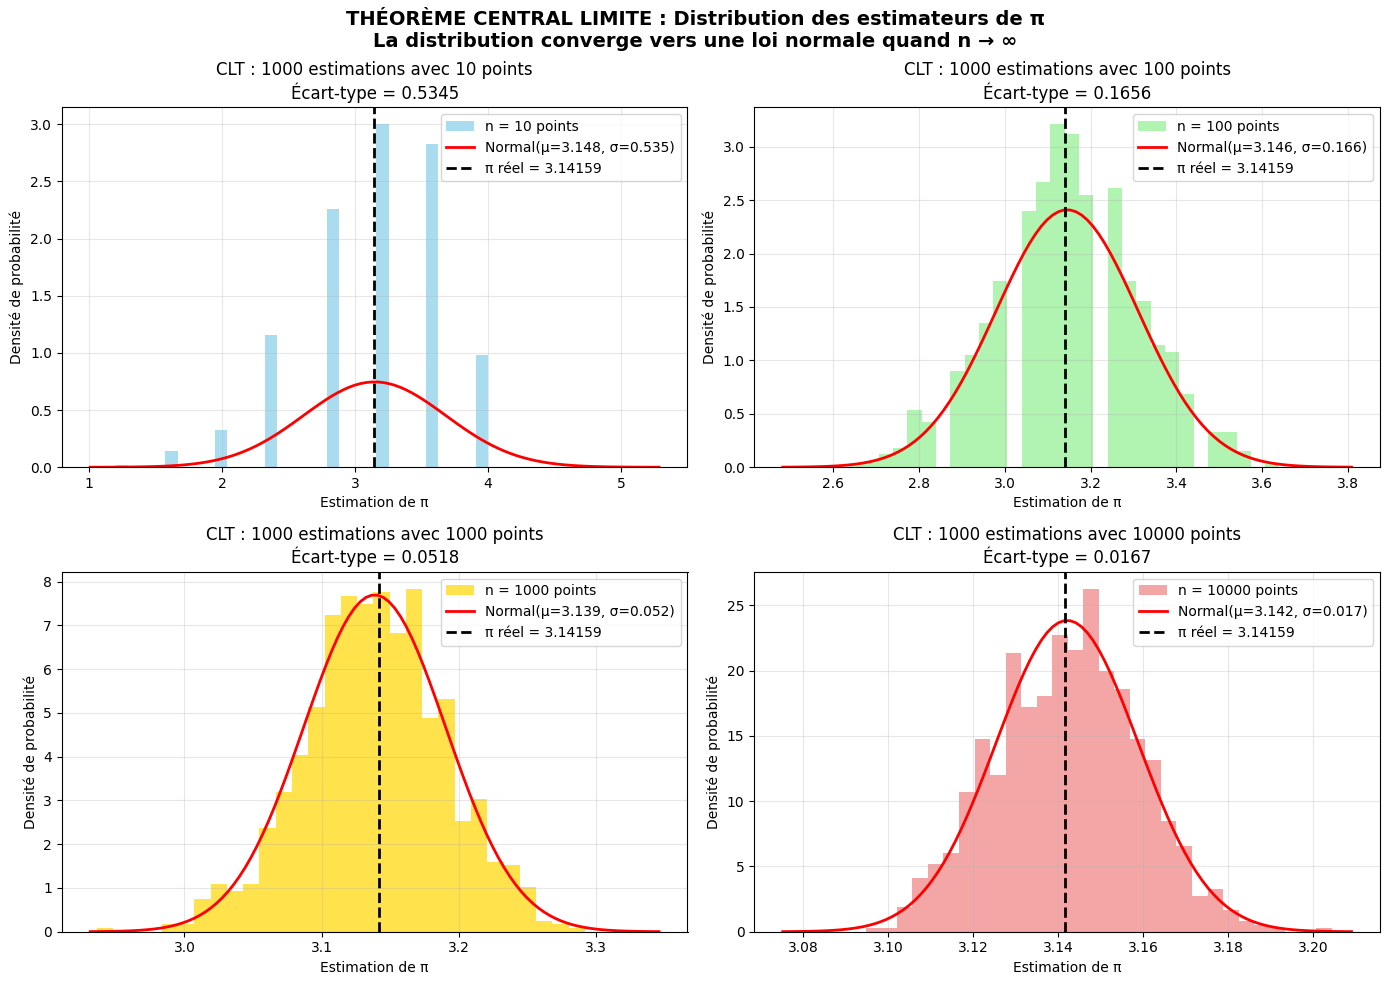


CONCLUSION - THÉORÈME CENTRAL LIMITE
 Pour n conséquent (1000+) : Distribution approximativement normale
 La variance diminue comme 1/√n
 La distribution se concentre autour de la valeur réelle π
 Écart-types observés :
   n =    10 : σ = 0.5345
   n =   100 : σ = 0.1656
   n =  1000 : σ = 0.0518
   n = 10000 : σ = 0.0167


In [70]:
def estimate_pi(n_points):
    """Estime π en utilisant n_points générés aléatoirement"""
    x = np.random.uniform(0, 1, n_points)
    y = np.random.uniform(0, 1, n_points)
    distances = x**2 + y**2
    inside_circle = np.sum(distances <= 1)
    return 4 * inside_circle / n_points

def multiple_pi_estimates(n_simulations, n_points):
    """Répète l'estimation de π plusieurs fois"""
    estimates = []
    for _ in range(n_simulations):
        estimates.append(estimate_pi(n_points))
    return np.array(estimates)



print("THÉORÈME CENTRAL LIMITE : Distribution des estimateurs de π")
print("="*70)

n_simulations = 1000
point_levels = [10, 100, 1000, 10000]

# Calcul des distributions
distributions = {}
print("Calcul des distributions...")
for n_points in point_levels:
    distributions[n_points] = multiple_pi_estimates(n_simulations, n_points)
    print(f"✓ {n_points} points : {n_simulations} simulations terminées")

#Histogramme

print("\n" + "="*70)
print("HISTOGRAMMES ")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['skyblue', 'lightgreen', 'gold', 'lightcoral']

for idx, n_points in enumerate(point_levels):
    data = distributions[n_points]
    mu, std = np.mean(data), np.std(data)

    # Histogramme
    n, bins, patches = axes[idx].hist(data, bins=30, density=True, alpha=0.7,
                                     color=colors[idx], label=f'n = {n_points} points')

    # Courbe normale théorique
    x = np.linspace(mu - 4*std, mu + 4*std, 100)
    axes[idx].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2,
                  label=f'Normal(μ={mu:.3f}, σ={std:.3f})')

    # Valeur réelle de référence pi
    axes[idx].axvline(np.pi, color='black', linestyle='--', linewidth=2,
                     label='π réel = 3.14159')

    axes[idx].set_xlabel('Estimation de π')
    axes[idx].set_ylabel('Densité de probabilité')
    axes[idx].set_title(f'CLT : {n_simulations} estimations avec {n_points} points\n'
                       f'Écart-type = {std:.4f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('THÉORÈME CENTRAL LIMITE : Distribution des estimateurs de π\n'
             'La distribution converge vers une loi normale quand n → ∞',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# CONCLUSION

print("\n" + "="*70)
print("CONCLUSION - THÉORÈME CENTRAL LIMITE")
print("="*70)


print(" Pour n conséquent (1000+) : Distribution approximativement normale")
print(" La variance diminue comme 1/√n")
print(" La distribution se concentre autour de la valeur réelle π")

print(" Écart-types observés :")
for n_points in point_levels:
    std = np.std(distributions[n_points])
    print(f"   n = {n_points:5d} : σ = {std:.4f}")
